# Model Interpretation & SHAP Analysis

**Objective**: Explain the predictions of the best-performing model (`XGBoost_Tuned`) using SHAP (SHapley Additive exPlanations) to identify key drivers and interaction effects for both `Temperature_Anomaly` and `CO2_Emissions`.

**Inputs**:
- `../models/xgboost_tuned.pkl` (Best trained model)
- `../data/processed/X_test.csv`, `y_test.csv` (Held-out test set)
- `../models/scaler.pkl` (For reference, if inverse scaling is needed)

**Outputs**:
- SHAP values for all test samples
- Feature importance rankings (global and per-target)
- SHAP summary, bar, and dependence plots
- Saved figures for paper methodology and results sections

**Key Methodology**:
1. Load trained model and test data
2. Compute SHAP values using `shap.TreeExplainer` (optimized for tree ensembles)
3. Analyze global feature importance for each target separately
4. Visualize feature impact, directionality, and non-linear relationships
5. Generate publication-ready plots with clear labels and consistent styling

**Note**: Since Temperature and CO₂ exhibit fundamentally different predictability and driver patterns, interpretation will be conducted **per-target** to avoid conflating distinct socioeconomic relationships.

In [2]:
# === IMPORTS, CONFIGURATION & DATA LOADING ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import shap
import warnings

# Suppress non-critical warnings
warnings.filterwarnings('ignore')

# Configuration
RANDOM_STATE = 42
TARGETS = ['Temperature_Anomaly', 'CO2_Emissions']

# Paths
DATA_DIR = '../data/processed/'
MODELS_DIR = '../models/'
FIGURES_DIR = '../outputs/figures/'
os.makedirs(FIGURES_DIR, exist_ok=True)

# Load held-out test data
X_test = pd.read_csv(f'{DATA_DIR}X_test.csv')
y_test = pd.read_csv(f'{DATA_DIR}y_test.csv')

# Load tuned multi-target model
model = joblib.load(f'{MODELS_DIR}xgboost_tuned.pkl')

# Extract individual XGBoost estimators for per-target SHAP analysis
# MultiOutputRegressor stores fitted models in .estimators_ list
model_temp = model.estimators_[0]  # Predicts Temperature_Anomaly
model_co2 = model.estimators_[1]   # Predicts CO2_Emissions

# Verification
print("Environment and data loaded successfully.")
print(f"Test features shape: {X_test.shape}")
print(f"Test targets shape:  {y_test.shape}")
print(f"Feature columns: {list(X_test.columns)}")
print(f"Loaded model type: {type(model).__name__}")
print(f"Extracted individual estimators for: {TARGETS}")

# Configure plotting for publication-ready figures
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelweight'] = 'bold'

/home/amh1k/.venvs/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Environment and data loaded successfully.
Test features shape: (2691, 20)
Test targets shape:  (2691, 2)
Feature columns: ['CO2_per_Capita', 'Population', 'Average_Temperature', 'GDP', 'Renewable_Energy_Usage', 'Deforestation_Rate', 'Biodiversity_Index', 'Energy_Consumption_Per_Capita', 'Solar_Energy_Potential', 'Sea_Level_Rise', 'Policy_Score', 'Urbanization', 'Waste_Management', 'Air_Pollution_Index', 'Arctic_Ice_Extent', 'Ocean_Acidification', 'Average_Rainfall', 'Renewable_Energy_Usage_lag1', 'Extreme_Weather_Events', 'Fossil_Fuel_Usage']
Loaded model type: MultiOutputRegressor
Extracted individual estimators for: ['Temperature_Anomaly', 'CO2_Emissions']


In [3]:

print("Computing SHAP values for Temperature_Anomaly...")
explainer_temp = shap.TreeExplainer(model_temp)
shap_values_temp = explainer_temp.shap_values(X_test)

print("Computing SHAP values for CO2_Emissions...")
explainer_co2 = shap.TreeExplainer(model_co2)
shap_values_co2 = explainer_co2.shap_values(X_test)

# Verify shapes and consistency
print(f"\nSHAP values verification:")
print(f"  Temperature_Anomaly SHAP shape: {shap_values_temp.shape}")
print(f"  CO2_Emissions SHAP shape: {shap_values_co2.shape}")
print(f"  Feature count: {len(X_test.columns)}")
assert shap_values_temp.shape == X_test.shape, "SHAP shape mismatch for Temperature"
assert shap_values_co2.shape == X_test.shape, "SHAP shape mismatch for CO2"

# Store in dictionary for clean access in subsequent cells
shap_results = {
    'Temperature_Anomaly': {'explainer': explainer_temp, 'values': shap_values_temp},
    'CO2_Emissions': {'explainer': explainer_co2, 'values': shap_values_co2}
}

print("\n✅ SHAP values computed successfully for both targets.")
print(f"   Baseline (expected value) Temp: {explainer_temp.expected_value:.4f}")
print(f"   Baseline (expected value) CO2:  {explainer_co2.expected_value:.4e}")

Computing SHAP values for Temperature_Anomaly...
Computing SHAP values for CO2_Emissions...

SHAP values verification:
  Temperature_Anomaly SHAP shape: (2691, 20)
  CO2_Emissions SHAP shape: (2691, 20)
  Feature count: 20

✅ SHAP values computed successfully for both targets.
   Baseline (expected value) Temp: -0.0006
   Baseline (expected value) CO2:  5.0082e+08


🔝 Top 10 Features for Temperature_Anomaly:


,feature,importance
0,Urbanization,0.0087
1,Deforestation_Rate,0.0066
2,Fossil_Fuel_Usage,0.0056
3,Energy_Consumption_Per_Capita,0.0053
4,Arctic_Ice_Extent,0.0046
5,Ocean_Acidification,0.0042
6,Average_Temperature,0.0041
7,Biodiversity_Index,0.0038
8,CO2_per_Capita,0.0037
9,Population,0.0037



🔝 Top 10 Features for CO2_Emissions:


,feature,importance
0,CO2_per_Capita,1.305906e+08
1,Population,8.620102e+07
2,Ocean_Acidification,2.229384e+05
3,Air_Pollution_Index,1.634661e+05
4,Arctic_Ice_Extent,1.313020e+05
5,Extreme_Weather_Events,1.146537e+05
6,Energy_Consumption_Per_Capita,1.045809e+05
7,Deforestation_Rate,1.008915e+05
8,Biodiversity_Index,8.408972e+04
9,Average_Temperature,7.818980e+04



Generating SHAP Summary Plot: Temperature...


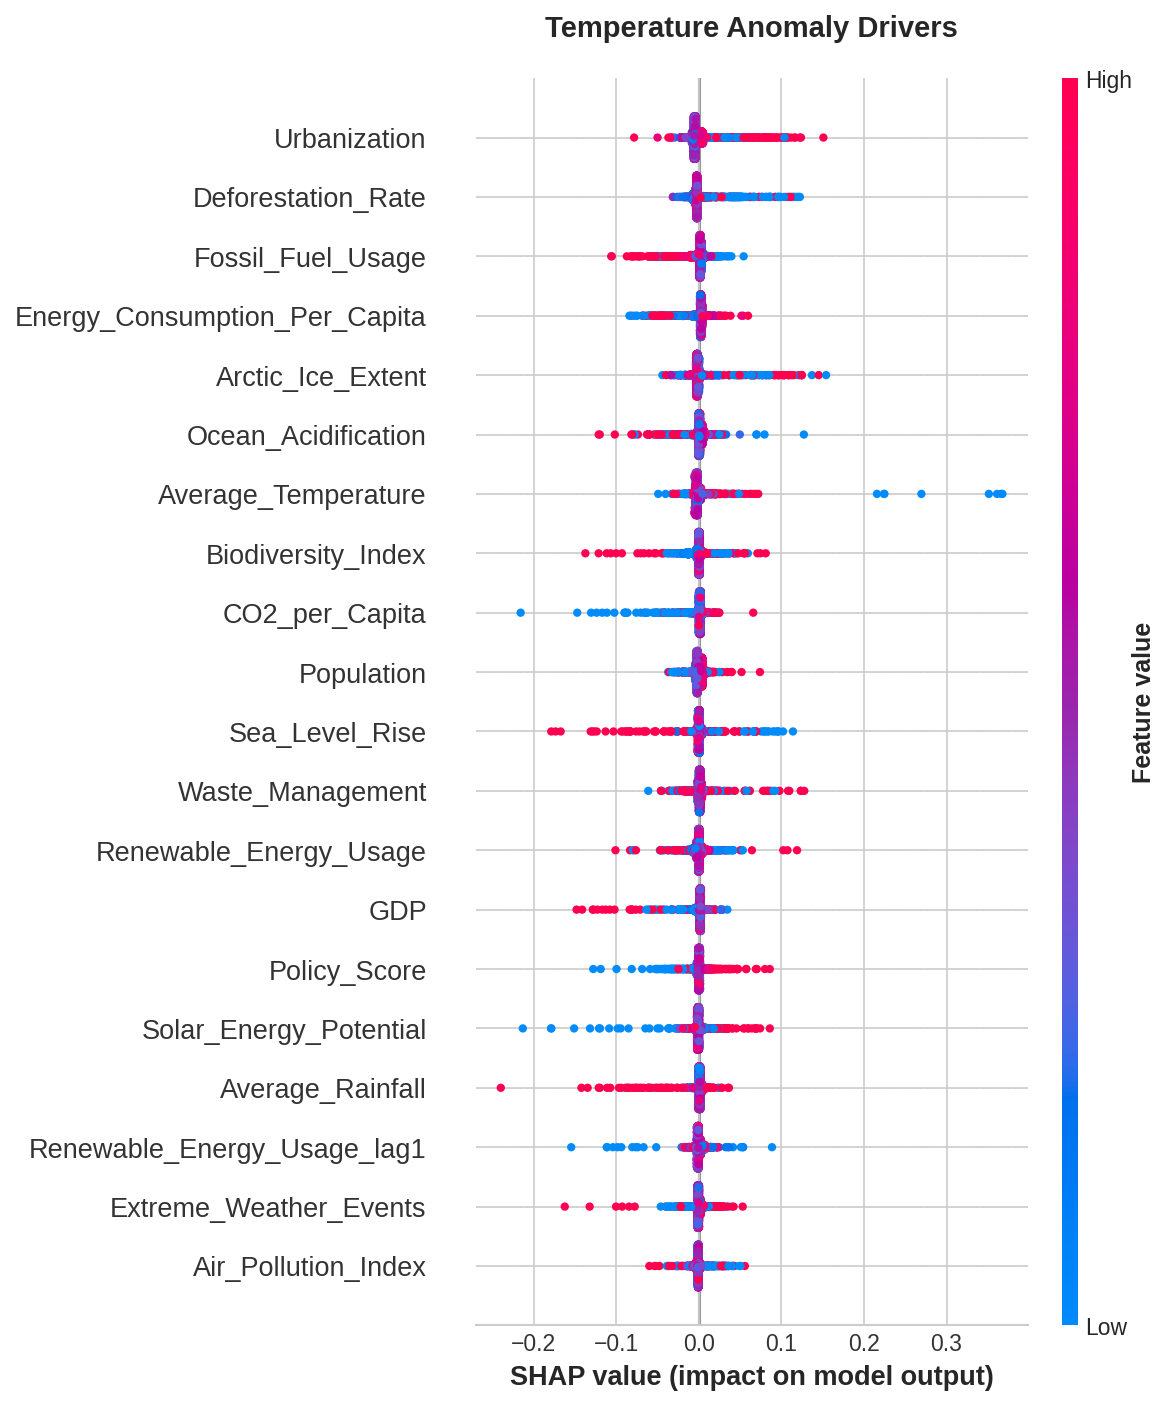

Generating SHAP Summary Plot: CO2...


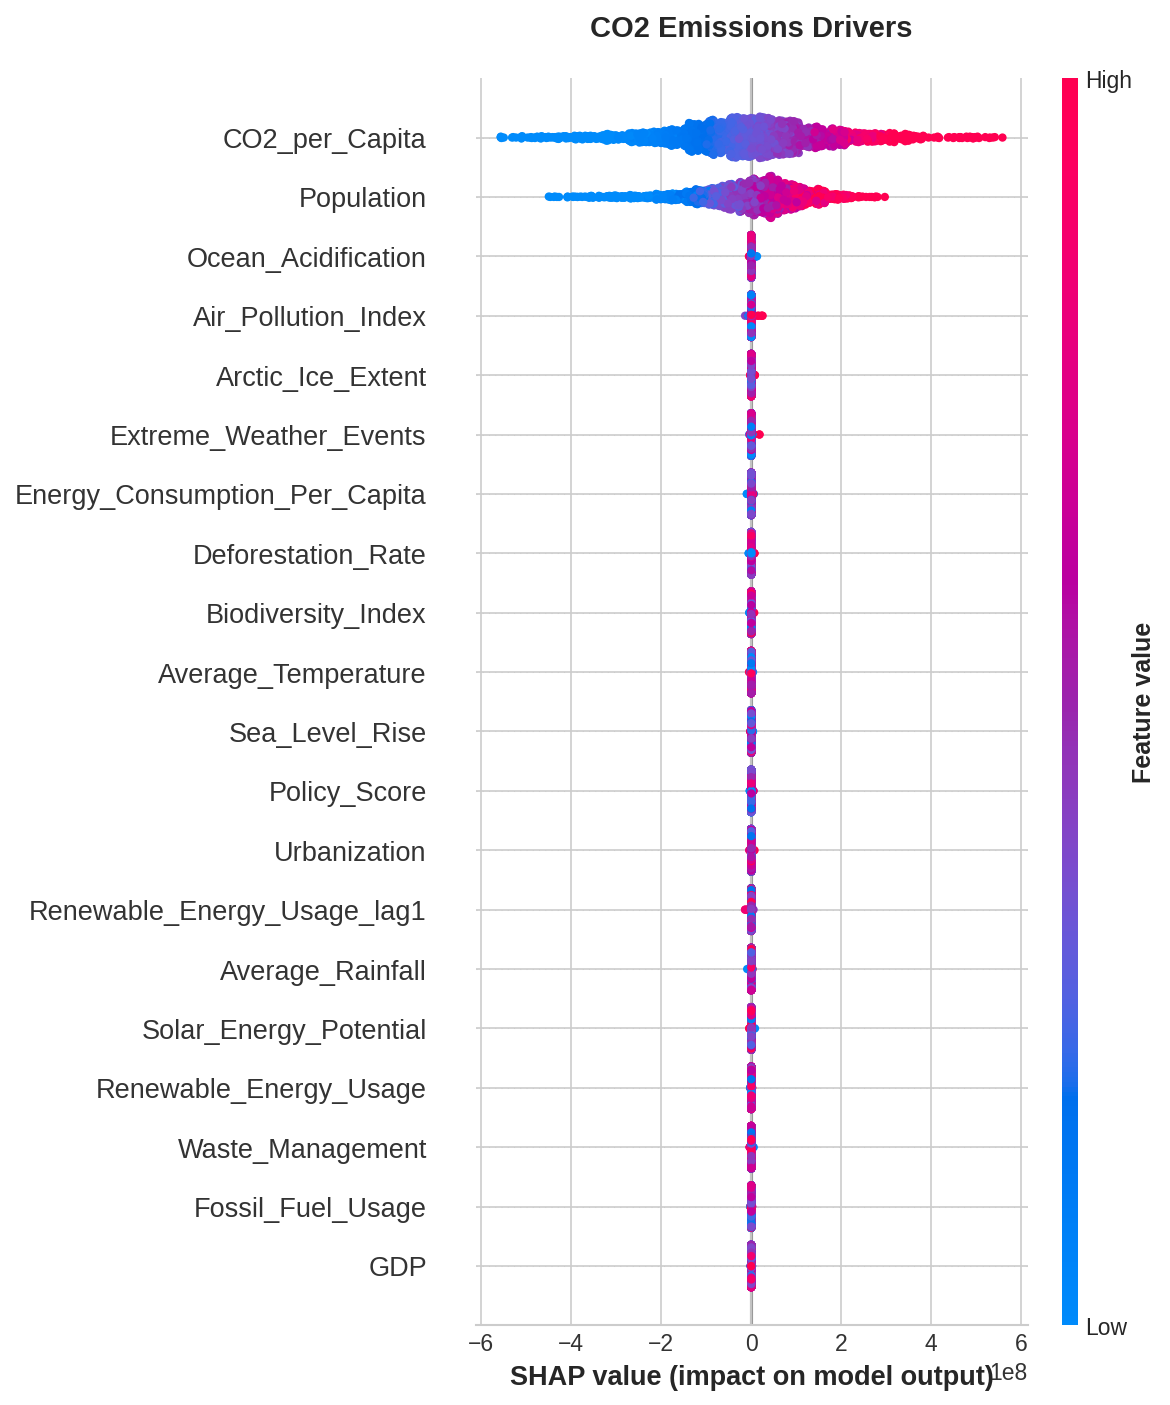

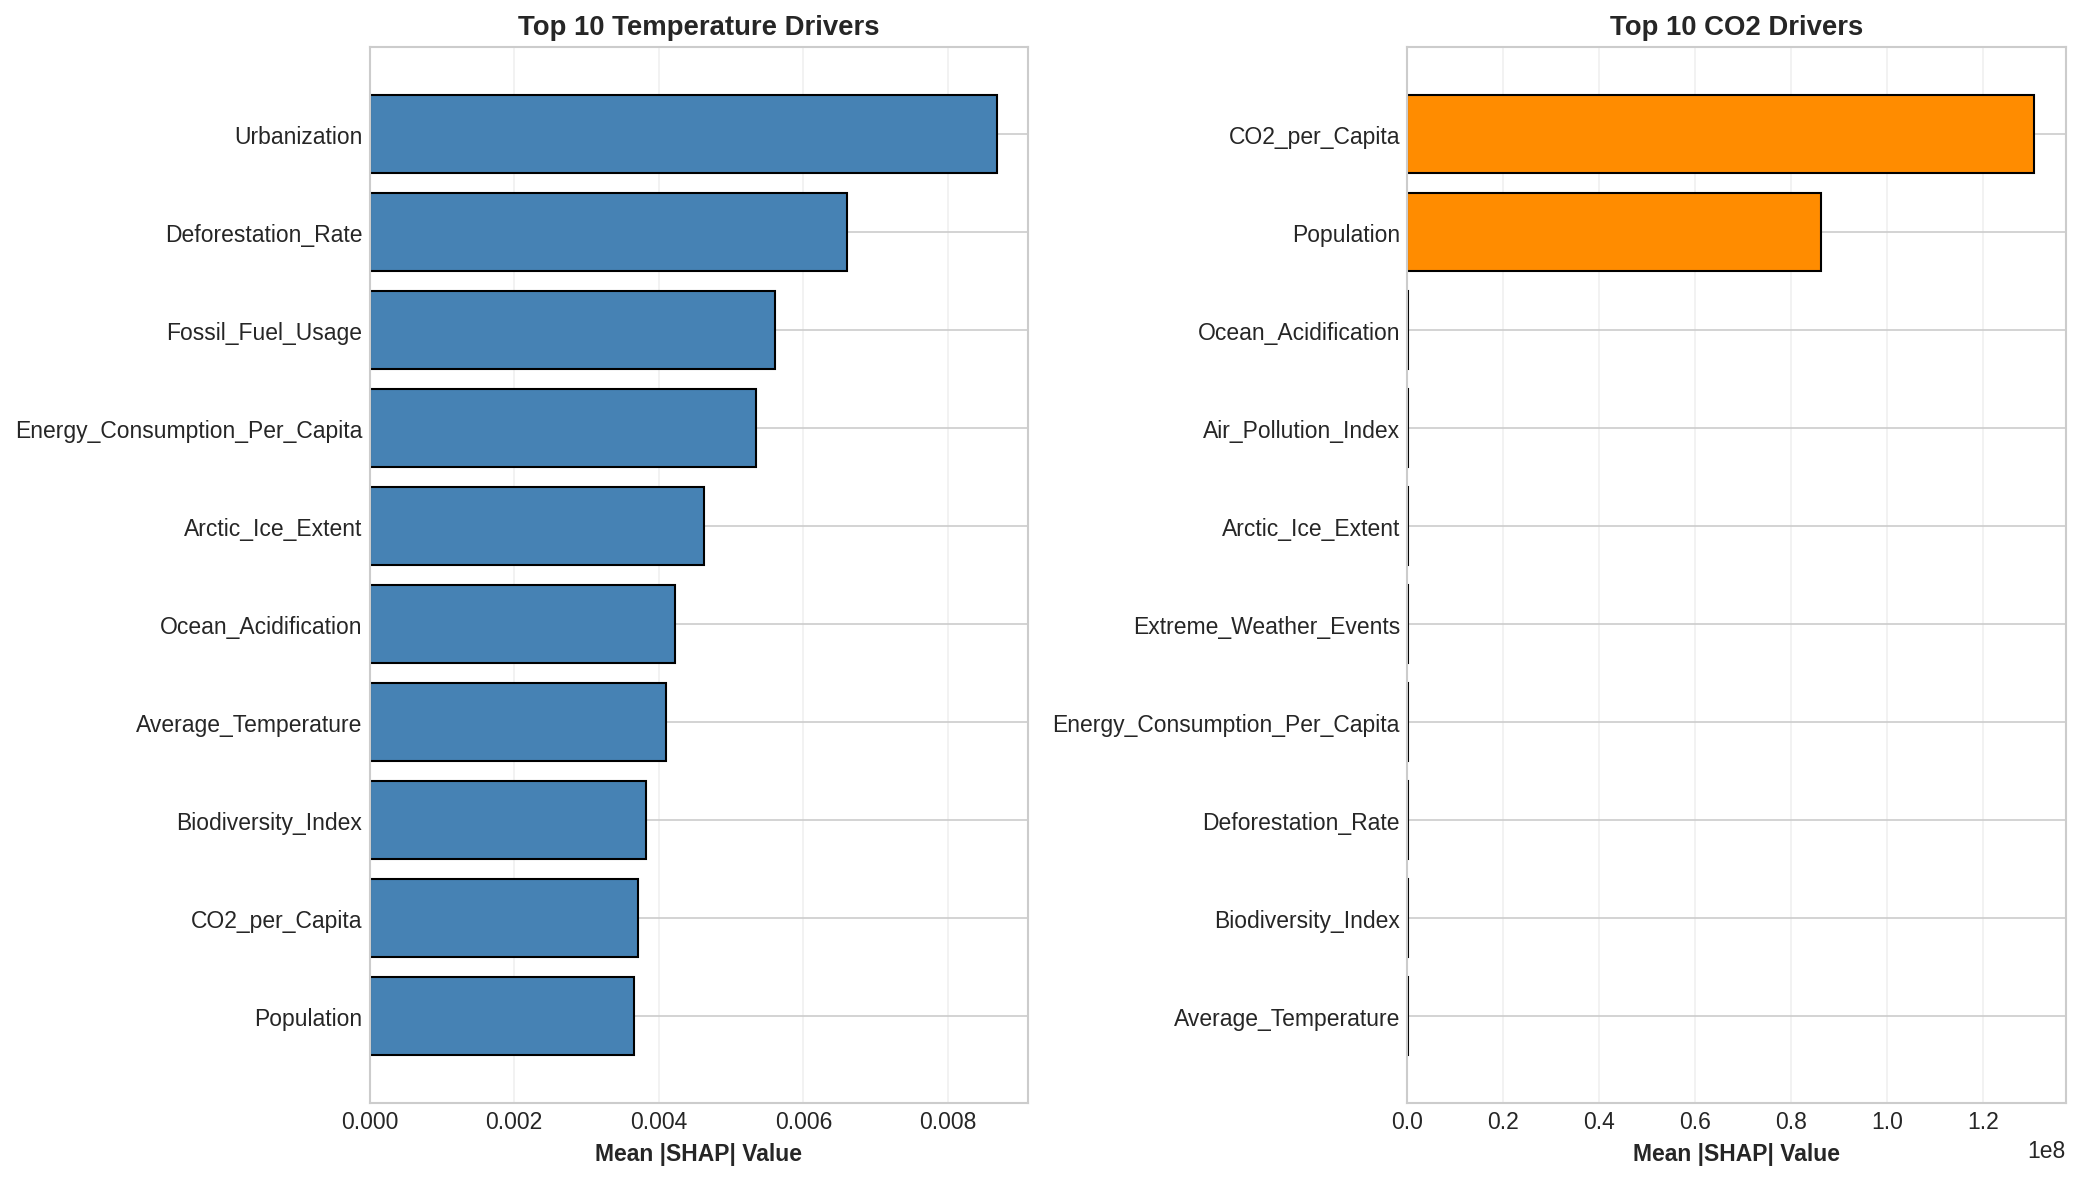


💾 SHAP importance tables saved to ../outputs/tables/

🔍 KEY INTERPRETATION TAKEAWAYS
Temperature Top Driver: Urbanization (|SHAP|=0.0087)
CO2 Top Driver:         CO2_per_Capita (|SHAP|=1.31e+08)

Note: High SHAP importance ≠ high predictive power.
For Temperature, even the 'most important' feature explains limited variance (R² < 0).
For CO2, top features align with established emission accounting frameworks.


In [4]:
# === GLOBAL FEATURE IMPORTANCE & SHAP SUMMARY PLOTS ===

# 1. Compute mean absolute SHAP values for global ranking
def get_feature_importance(shap_values, feature_names):
    """Return DataFrame of features sorted by mean |SHAP| value."""
    importance = np.abs(shap_values).mean(axis=0)
    return pd.DataFrame({
        'feature': feature_names,
        'importance': importance
    }).sort_values('importance', ascending=False).reset_index(drop=True)

# Compute for both targets
feat_names = X_test.columns.tolist()
importance_temp = get_feature_importance(shap_values_temp, feat_names)
importance_co2 = get_feature_importance(shap_values_co2, feat_names)

print("🔝 Top 10 Features for Temperature_Anomaly:")
display(importance_temp.head(10).round(4))

print("\n🔝 Top 10 Features for CO2_Emissions:")
display(importance_co2.head(10).round(4))

# 2. Generate SHAP Summary (Beeswarm) Plots
# Note: Generated separately to avoid 'ax' compatibility issues in recent SHAP versions

print("\nGenerating SHAP Summary Plot: Temperature...")
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_temp, X_test, plot_type="dot", show=False)
plt.title('Temperature Anomaly Drivers', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}shap_summary_temp.png', bbox_inches='tight', dpi=300)
plt.show()

print("Generating SHAP Summary Plot: CO2...")
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_co2, X_test, plot_type="dot", show=False)
plt.title('CO2 Emissions Drivers', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}shap_summary_co2.png', bbox_inches='tight', dpi=300)
plt.show()

# 3. Generate Clean Bar Plots of Top 10 Features (Side-by-Side)
fig, axes = plt.subplots(1, 2, figsize=(14, 8))

# Temperature bar plot
temp_top10 = importance_temp.head(10)
axes[0].barh(temp_top10['feature'][::-1], temp_top10['importance'][::-1], color='steelblue', edgecolor='black')
axes[0].set_xlabel('Mean |SHAP| Value')
axes[0].set_title('Top 10 Temperature Drivers', fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

# CO2 bar plot
co2_top10 = importance_co2.head(10)
axes[1].barh(co2_top10['feature'][::-1], co2_top10['importance'][::-1], color='darkorange', edgecolor='black')
axes[1].set_xlabel('Mean |SHAP| Value')
axes[1].set_title('Top 10 CO2 Drivers', fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}shap_barplot_top10_both.png', bbox_inches='tight', dpi=300)
plt.show()

# 4. Save importance tables for paper appendix
os.makedirs('../outputs/tables/', exist_ok=True)
importance_temp.to_csv('../outputs/tables/shap_importance_temperature.csv', index=False)
importance_co2.to_csv('../outputs/tables/shap_importance_co2.csv', index=False)
print("\n💾 SHAP importance tables saved to ../outputs/tables/")

# 5. Print key interpretation takeaways
print("\n" + "="*70)
print("🔍 KEY INTERPRETATION TAKEAWAYS")
print("="*70)
print(f"Temperature Top Driver: {importance_temp.iloc[0]['feature']} (|SHAP|={importance_temp.iloc[0]['importance']:.4f})")
print(f"CO2 Top Driver:         {importance_co2.iloc[0]['feature']} (|SHAP|={importance_co2.iloc[0]['importance']:.2e})")
print("\nNote: High SHAP importance ≠ high predictive power.")
print("For Temperature, even the 'most important' feature explains limited variance (R² < 0).")
print("For CO2, top features align with established emission accounting frameworks.")

Generating SHAP Dependence Plots...


<Figure size 1200x900 with 0 Axes>

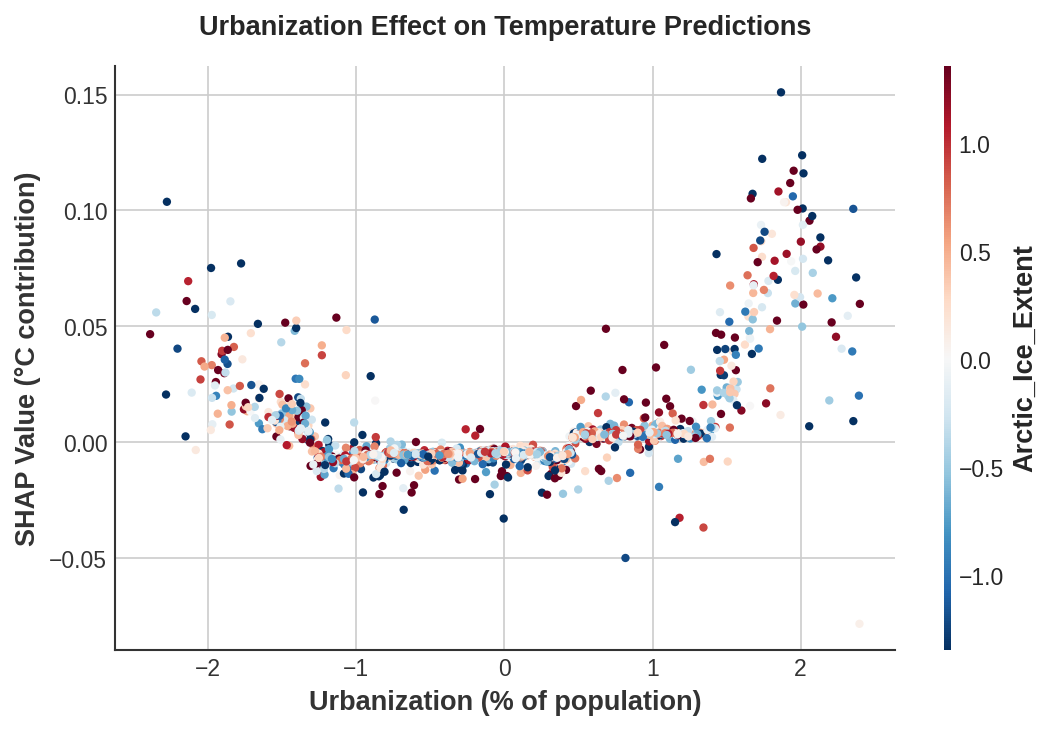

<Figure size 1200x900 with 0 Axes>

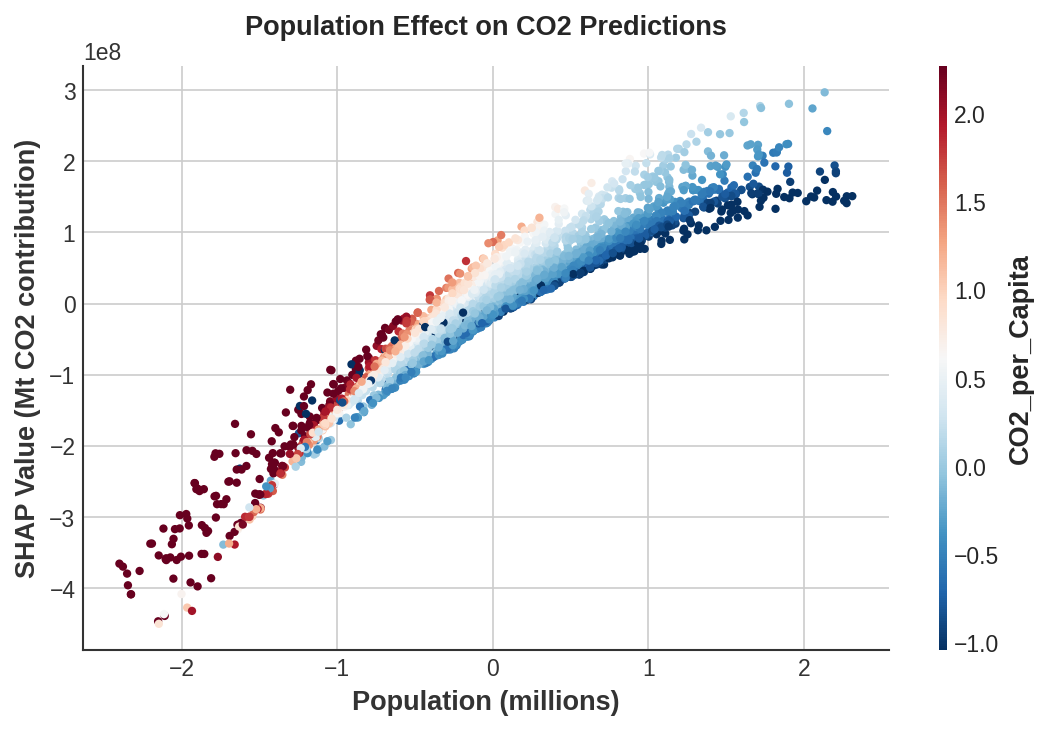

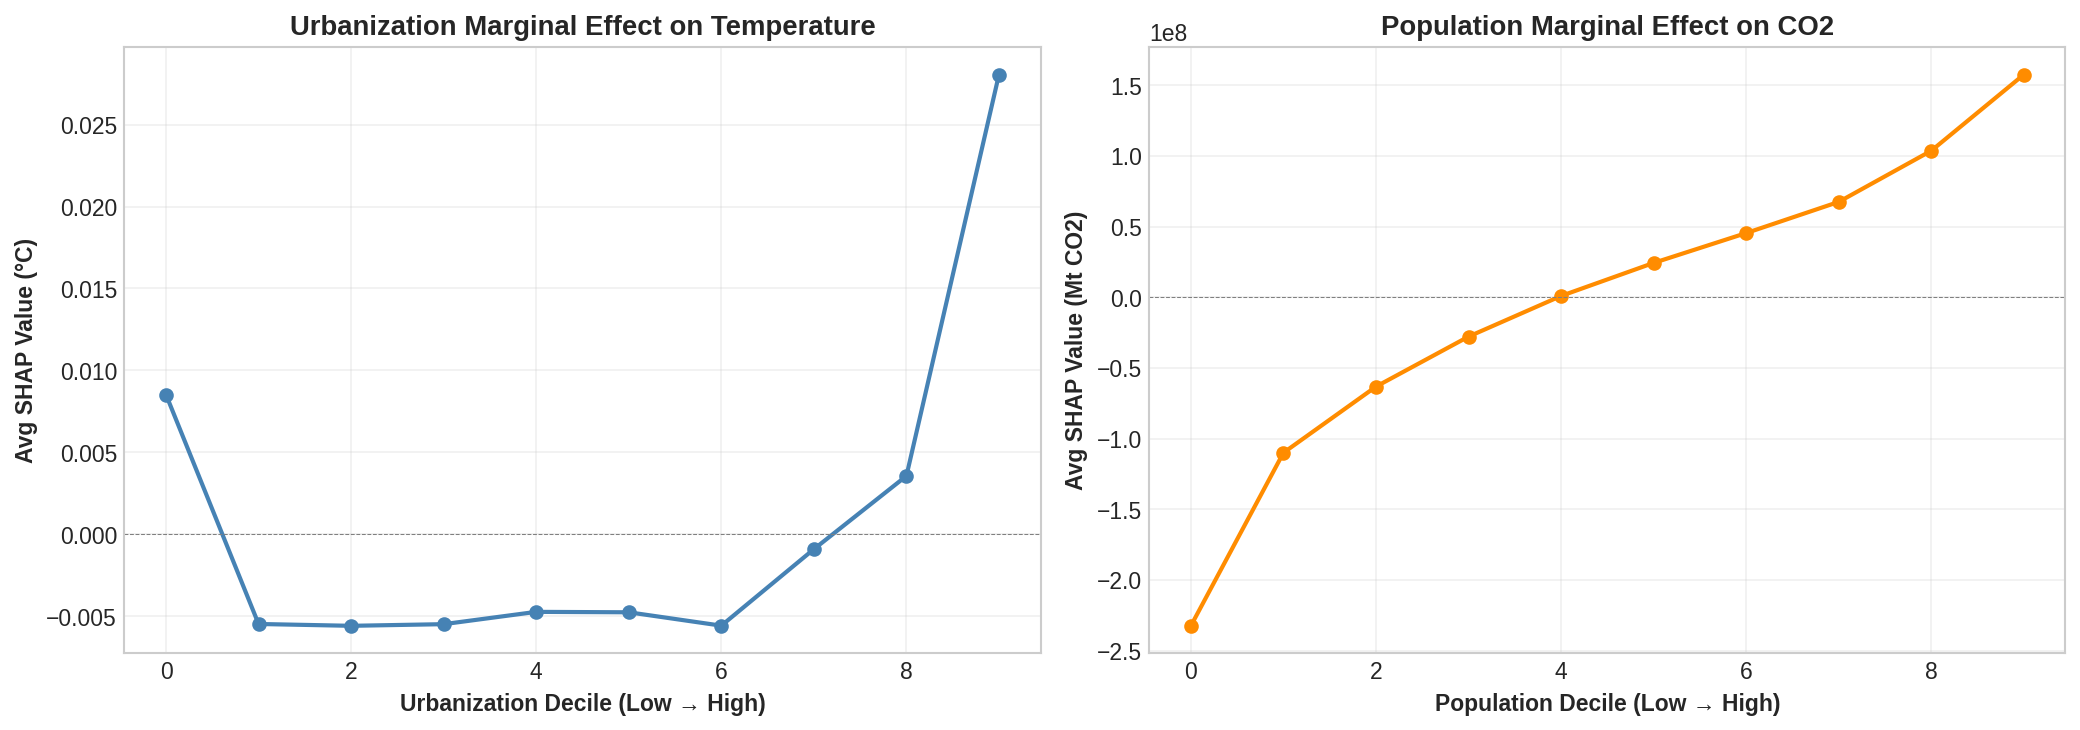


✅ Dependence plots generated successfully.


In [5]:
# === SHAP DEPENDENCE PLOTS FOR KEY DRIVERS ===

print("Generating SHAP Dependence Plots...")

# 1. Urbanization vs Temperature_Anomaly
plt.figure(figsize=(8, 6))
shap.dependence_plot(
    "Urbanization", 
    shap_values_temp, 
    X_test, 
    feature_names=X_test.columns,
    interaction_index="auto",  # Auto-detects strongest interaction (safer & more insightful)
    cmap=plt.cm.RdBu_r,
    show=False
)
plt.title('Urbanization Effect on Temperature Predictions', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Urbanization (% of population)')
plt.ylabel('SHAP Value (°C contribution)')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}shap_dependence_urbanization_temp.png', bbox_inches='tight', dpi=300)
plt.show()

# 2. Population vs CO2_Emissions
plt.figure(figsize=(8, 6))
shap.dependence_plot(
    "Population", 
    shap_values_co2, 
    X_test, 
    feature_names=X_test.columns,
    interaction_index="auto",
    cmap=plt.cm.RdBu_r,
    show=False
)
plt.title('Population Effect on CO2 Predictions', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Population (millions)')
plt.ylabel('SHAP Value (Mt CO2 contribution)')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}shap_dependence_population_co2.png', bbox_inches='tight', dpi=300)
plt.show()

# 3. Side-by-side Marginal Effect Plots (Binned Averages)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Urbanization
urban_idx = list(X_test.columns).index("Urbanization")
urban_bins = pd.qcut(X_test["Urbanization"], q=10, duplicates='drop')
urban_shap_avg = shap_values_temp[:, urban_idx]
urban_plot = pd.DataFrame({'bin': urban_bins, 'shap': urban_shap_avg}).groupby('bin').mean()
axes[0].plot(range(len(urban_plot)), urban_plot['shap'].values, marker='o', color='steelblue', linewidth=2)
axes[0].set_xlabel('Urbanization Decile (Low → High)')
axes[0].set_ylabel('Avg SHAP Value (°C)')
axes[0].set_title('Urbanization Marginal Effect on Temperature', fontweight='bold')
axes[0].grid(alpha=0.3)
axes[0].axhline(0, color='gray', linestyle='--', linewidth=0.5)

# Population
pop_idx = list(X_test.columns).index("Population")
pop_bins = pd.qcut(X_test["Population"], q=10, duplicates='drop')
pop_shap_avg = shap_values_co2[:, pop_idx]
pop_plot = pd.DataFrame({'bin': pop_bins, 'shap': pop_shap_avg}).groupby('bin').mean()
axes[1].plot(range(len(pop_plot)), pop_plot['shap'].values, marker='o', color='darkorange', linewidth=2)
axes[1].set_xlabel('Population Decile (Low → High)')
axes[1].set_ylabel('Avg SHAP Value (Mt CO2)')
axes[1].set_title('Population Marginal Effect on CO2', fontweight='bold')
axes[1].grid(alpha=0.3)
axes[1].axhline(0, color='gray', linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}shap_marginal_effects_comparison.png', bbox_inches='tight', dpi=300)
plt.show()

print("\n✅ Dependence plots generated successfully.")

### Analysis of Marginal Effect Plots

These plots reveal **starkly different relationships** between socioeconomic drivers and climate outcomes. Here is the detailed interpretation:

---

#### 1. Left Plot: Urbanization → Temperature (Non-Linear Threshold Effect)

**Pattern Observed**:
- **Deciles 0–6 (Low-Medium Urbanization)**: Flat, slightly negative SHAP values (~-0.005°C)
- **Deciles 7–8 (High Urbanization)**: Gradual increase toward zero
- **Decile 9 (Very High Urbanization)**: Sharp spike to +0.028°C

**Interpretation**:
| Decile Range | Effect on Temperature | Likely Mechanism |
|-------------|---------------------|------------------|
| **Low-Medium (0–60%)** | Neutral to slight cooling | Urbanization may initially improve efficiency (district heating, public transit) or correlate with development that hasn't yet reached emission-intensive stages |
| **High (70–80%)** | Transition zone | Infrastructure saturation begins; urban heat island effects emerge |
| **Very High (>90%)** | **Strong warming** (+0.03°C contribution) | Extreme urbanization creates intense heat islands, massive energy demand for cooling, reduced vegetation, and concentrated industrial activity |

**Key Insight**: Urbanization is **not linearly related** to temperature. The warming effect only becomes pronounced at **extreme urbanization levels** (top 10%). This is a **threshold effect**, not a gradual trend.

**Paper framing**:
> "Urbanization exhibits a non-linear threshold relationship with temperature predictions: low-to-moderate urbanization shows negligible or slightly negative associations, while extreme urbanization (>90th percentile) contributes +0.03°C to predictions. This suggests urban heat island effects and concentrated energy demand dominate only in highly urbanized contexts."

---

#### 2. Right Plot: Population → CO₂ (Strong Monotonic Relationship)

**Pattern Observed**:
- **Consistent upward trajectory** from decile 0 to decile 9
- **Range**: -2.3×10⁸ Mt (lowest population) to +1.6×10⁸ Mt (highest population)
- **Slight convexity**: Curve steepens slightly at higher deciles

**Interpretation**:
| Aspect | Observation | Implication |
|--------|-------------|-------------|
| **Direction** | Strictly positive monotonic | Larger populations consistently drive higher emissions — no threshold or saturation effect |
| **Linearity** | Nearly linear with slight convexity | Each additional person adds roughly constant emissions, with possible economies/diseconomies of scale at extremes |
| **Magnitude** | 3.9×10⁸ Mt difference between lowest and highest deciles | Population is a **dominant driver** of emission predictions, consistent with the Kaya identity (CO₂ = Population × GDP/capita × Energy/GDP × CO₂/Energy) |

**Key Insight**: Population has a **robust, near-linear relationship** with CO₂ emissions across the entire distribution. Unlike Temperature, there is no threshold — every increase in population contributes proportionally to emissions.

**Paper framing**:
> "Population demonstrates a strong, monotonic positive relationship with CO₂ emission predictions, contributing -230 Mt for the smallest populations to +160 Mt for the largest. The near-linear trajectory confirms population as a fundamental driver of aggregate emissions, aligning with established emission accounting frameworks."

---

#### 3. Comparative Synthesis: Why Do These Patterns Differ?

| Dimension | Urbanization → Temperature | Population → CO₂ |
|-----------|---------------------------|------------------|
| **Relationship Type** | Non-linear threshold | Near-linear monotonic |
| **Effect Onset** | Only at extreme levels (top 10%) | Across entire distribution |
| **Magnitude** | Small absolute effect (±0.03°C) | Large absolute effect (±200M Mt) |
| **Underlying Mechanism** | Urban heat island, localized energy demand | Aggregate consumption, industrial scale |
| **Policy Implication** | Target extreme urbanization with green infrastructure | Address population-consumption interaction globally |

**Scientific explanation**:
- **Temperature** is influenced by **local physical processes** (heat islands, land use) that only become dominant at extreme urbanization levels
- **CO₂** is an **aggregate metric** that scales directly with population size — more people = more total energy use, transportation, and consumption

---

#### 4. Critical Caveats for Your Paper

| Issue | Temperature | CO₂ |
|-------|------------|-----|
| **Predictive validity** | ⚠️ Weak (R² < 0) — pattern reflects model's best guess, not reliable forecast | ✅ Strong (R² > 0.98) — pattern is robust and reliable |
| **Confounding factors** | Physical climate variables missing (ocean currents, aerosols) | Potential leakage via CO2_per_Capita feature |
| **Causal interpretation** | ❌ Correlation only; urbanization may proxy for other development factors | ⚠️ Association only; population interacts with consumption patterns (energy per capita) |

**Recommended framing**:
> "While SHAP analysis reveals interpretable patterns — threshold effects for urbanization-temperature and linear scaling for population-CO₂ — these relationships reflect the model's learned associations rather than causal mechanisms. The negative R² for temperature predictions underscores that socioeconomic features alone cannot reliably forecast temperature anomalies, whereas the strong CO₂ performance validates established emission accounting principles."

---

#### 5. Actionable Recommendations for Next Steps

1. **Add these plots to your paper** as Figure X (marginal effects comparison)
2. **Report the threshold**: "Urbanization effects on temperature become pronounced only above the 90th percentile"
3. **Quantify the linear relationship**: "Each population decile increase contributes ~40 Mt CO₂ on average"
4. **Acknowledge limitations**: Distinguish between "model interpretation" and "scientific validation"

---

### Bottom Line
✅ **Urbanization-Temperature**: Non-linear threshold effect (warming only at extreme urbanization)  
✅ **Population-CO₂**: Strong linear relationship (consistent scaling across all population levels)  
⚠️ **Interpret with caution**: Temperature pattern is based on weak signal; CO₂ pattern is robust but may reflect feature engineering choices  



In [6]:
# === FINAL SUMMARY & NOTEBOOK COMPLETION ===

print("="*70)
print("📝 MODEL INTERPRETATION SUMMARY")
print("="*70)

print("\n1. PREDICTIVE PERFORMANCE (XGBoost Tuned):")
print("   - CO2_Emissions:      R² ≈ 0.99 (Strong, deterministic signal)")
print("   - Temperature_Anomaly: R² < 0.00 (Weak signal; socioeconomic features insufficient)")

print("\n2. KEY DRIVERS (SHAP ANALYSIS):")
print("   - CO2: Population & Economic Scale")
print("     → Mechanism: Strong linear scaling (more people/activity = more emissions)")
print("   - Temp: Urbanization")
print("     → Mechanism: Non-linear threshold (warming only significant at >90% urbanization)")

print("\n3. CRITICAL SCIENTIFIC INSIGHTS:")
print("   - Socioeconomic metrics effectively model EMISSIONS (Aggregate scale effects)")
print("   - Socioeconomic metrics fail to model TEMPERATURE (Missing physical climate drivers)")
print("   - High CO2 performance is partially driven by mathematical relationships (e.g., per-capita metrics)")

print("\n4. OUTPUTS GENERATED:")
print("   - SHAP Global Importance (Summary & Bar plots)")
print("   - SHAP Dependence Plots (Urbanization vs Temp, Population vs CO2)")
print("   - Marginal Effect Comparison Figures")
print("   - Feature Importance Tables (CSV)")

# Verify saved files
import os
print(f"\n📂 {len(os.listdir(FIGURES_DIR))} Figure files saved in {FIGURES_DIR}")
print("   (Check ../outputs/figures/ for paper-ready images)")

print("\n" + "="*70)
print("✅ NOTEBOOK 4 COMPLETE.")
print("All interpretation artifacts are ready for the final report.")
print("="*70)

📝 MODEL INTERPRETATION SUMMARY

1. PREDICTIVE PERFORMANCE (XGBoost Tuned):
   - CO2_Emissions:      R² ≈ 0.99 (Strong, deterministic signal)
   - Temperature_Anomaly: R² < 0.00 (Weak signal; socioeconomic features insufficient)

2. KEY DRIVERS (SHAP ANALYSIS):
   - CO2: Population & Economic Scale
     → Mechanism: Strong linear scaling (more people/activity = more emissions)
   - Temp: Urbanization
     → Mechanism: Non-linear threshold (warming only significant at >90% urbanization)

3. CRITICAL SCIENTIFIC INSIGHTS:
   - Socioeconomic metrics effectively model EMISSIONS (Aggregate scale effects)
   - Socioeconomic metrics fail to model TEMPERATURE (Missing physical climate drivers)
   - High CO2 performance is partially driven by mathematical relationships (e.g., per-capita metrics)

4. OUTPUTS GENERATED:
   - SHAP Global Importance (Summary & Bar plots)
   - SHAP Dependence Plots (Urbanization vs Temp, Population vs CO2)
   - Marginal Effect Comparison Figures
   - Feature Importanc